## Exploring

In [1]:
import pandas as pd
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
pd.set_option('display.max_columns', None)

In [2]:
# Load in data frames
student_df = pd.read_csv(r"Clean Datasets\student_analysis_df.csv", dtype={'YearDistrict ID': str, 'DISTRICT': str})
staff_df = pd.read_csv(r"Clean Datasets\staff_analysis_df.csv", dtype={'YearDistrict ID': str, 'DISTRICT': str})


In [3]:
# CREATE: student_count_yoy 
col_to_keep = ['Year', 'All Students Count', 'Special Ed Count', 'Bilingual/ESL Count', 'Gifted & Talented Count', 'EB/EL Count', 
               'Econ Disadv Count','Non-Educationally Disadv Count', 'At Risk Count','Total Students with Disabilities Count',
               'Intellectual Disabilities Count', 'Physical Disabilities Count','Behavioral Disabilities Count', 'Autism Count',
               'Non-Categorical Early Childhood Count']

student_count_yoy_df = student_df[col_to_keep].groupby('Year').sum().reset_index()

student_count_yoy_df['YoY % Change'] = student_count_yoy_df['All Students Count'].pct_change() * 100
student_count_yoy_df['YoY Difference'] = student_count_yoy_df['All Students Count'].diff()

pre_covid_baseline = student_count_yoy_df.loc[student_count_yoy_df['Year']==2017, 'All Students Count'].item()
student_count_yoy_df['Covid Recovery'] = student_count_yoy_df['All Students Count'] - pre_covid_baseline


student_count_yoy = student_count_yoy_df[student_count_yoy_df["Year"]>=2017]

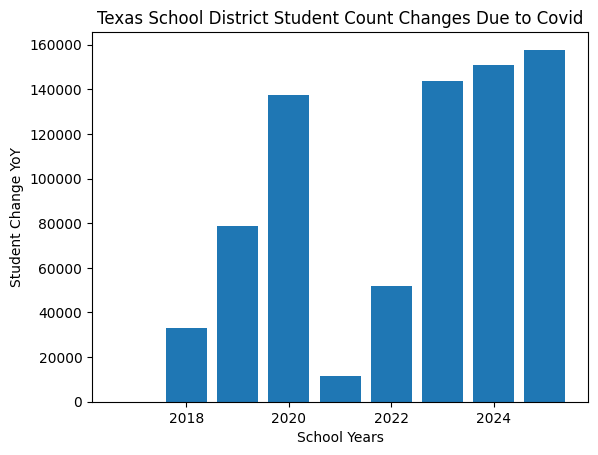

In [4]:
# VIZ: Bar chart that visualizing covid change

plt.bar(student_count_yoy_df['Year'],  student_count_yoy_df['Covid Recovery'])

# Add labels and a legend
plt.xlabel('School Years')
plt.ylabel('Student Change YoY')
plt.title('Texas School District Student Count Changes Due to Covid')

plt.show()

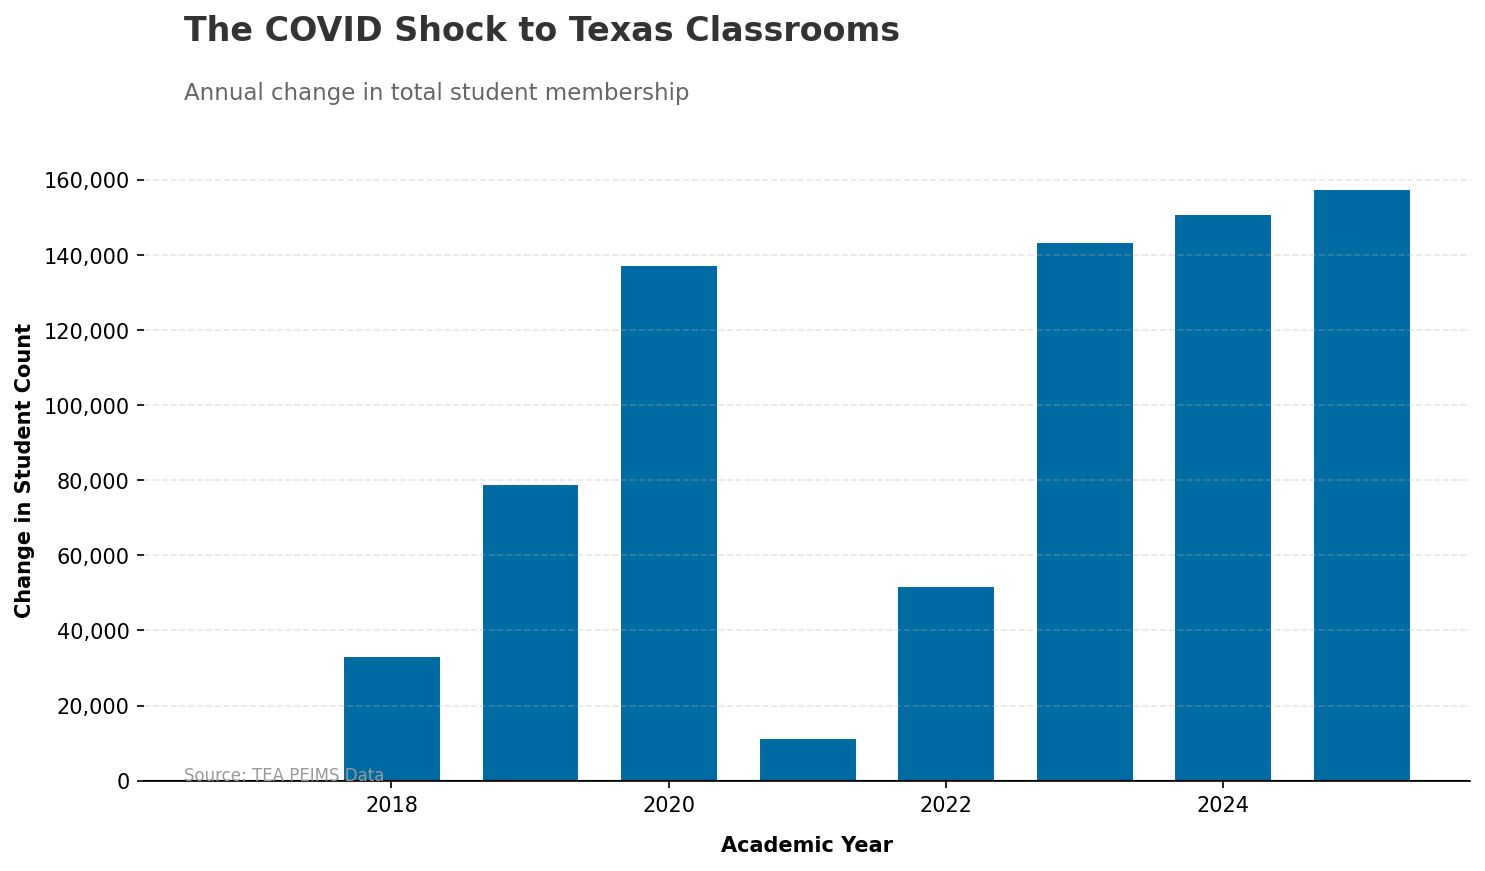

In [5]:
# VIZ: Create visually sexy style chart

# Set the professional figure size and DPI
plt.figure(figsize=(10, 6), dpi=150)

# 1. Create the bars with conditional coloring (Red for the drop, Blue for recovery)
# Using your specific column names
colors = ['#e3120b' if x < 0 else '#006ba2' for x in student_count_yoy_df['Covid Recovery']]

plt.bar(student_count_yoy_df['Year'], student_count_yoy_df['Covid Recovery'], 
        color=colors, width=0.7, edgecolor='white', linewidth=0.5)

# 2. The Baseline (Your red line, made slightly cleaner)
plt.axhline(y=0, color='black', linestyle='-', linewidth=1.5)

# 3. Formatting the style axes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}')) # Add commas to numbers
ax.yaxis.grid(True, linestyle='--', alpha=0.3) # Subtle horizontal grid only

# 4. Title & Labeling
# Use 'plt.text' for the main title to align it to the far left (standard professional style)
plt.text(x=student_count_yoy_df['Year'].min()-0.5, 
         y=student_count_yoy['Covid Recovery'].max() * 1.25, 
         s='The COVID Shock to Texas Classrooms', 
         fontsize=16, fontweight='bold', color='#333333')

plt.text(x=student_count_yoy_df['Year'].min()-0.5, 
         y=student_count_yoy_df['Covid Recovery'].max() * 1.15, 
         s='Annual change in total student membership', 
         fontsize=11, color='#666666')

plt.xlabel('Academic Year', fontsize=10, fontweight='bold', labelpad=10)
plt.ylabel('Change in Student Count', fontsize=10, fontweight='bold')

# 5. Add a source tag at the bottom
plt.text(x=student_count_yoy_df['Year'].min()-0.5, 
         y=student_count_yoy_df['Covid Recovery'].min() * -1.5, 
         s='Source: TEA PEIMS Data', fontsize=8, color='#999999')

plt.tight_layout()
plt.show()

In [6]:
# FILTER: REMOVE TINY DISTRICTS AND VALIDATE

DISTRICT_SIZE_THRESHOLD = 30  # Minimum "All Students Count" required

# Identify districts to remove
tiny_districts = (
    student_df[student_df["All Students Count"] <= DISTRICT_SIZE_THRESHOLD]["DISTRICT"]
    .unique()
)

years_count = student_df["Year"].nunique()
expected_removed = len(tiny_districts)
expected_rows_removed = len(tiny_districts) * years_count


# Capture shapes BEFORE filter
districts_before = (
    student_df
    .groupby("Year")["DISTRICT"]
    .nunique()
    .rename("districts_before")
)

student_shape_before = student_df.shape
staff_shape_before = staff_df.shape

# Apply filtering
student_df = (
    student_df[~student_df["DISTRICT"].isin(tiny_districts)]
    .reset_index(drop=True)
)

staff_df = (
    staff_df[~staff_df["DISTRICT"].isin(tiny_districts)]
    .reset_index(drop=True)
)

# Capture shapes AFTER filter
districts_after = (
    student_df
    .groupby("Year")["DISTRICT"]
    .nunique()
    .rename("districts_after")
)

student_shape_after = student_df.shape
staff_shape_after = staff_df.shape

# ============================================================
# VALIDATION
# ============================================================

# ----- Row validation -----

student_rows_removed = student_shape_before[0] - student_shape_after[0]
staff_rows_removed = staff_shape_before[0] - staff_shape_after[0]

print("\nFILTER VALIDATION")
print("--------------------------------------------------")

print("\nDISTRICT FILTER")
print(f"Tiny districts removed : {len(tiny_districts)}")
print(f"Years in dataset       : {years_count}")
print(f"Expected rows removed  : {expected_rows_removed}")

print("\nROW COUNTS")

print("Students")
print(f"  Before               : {student_shape_before[0]}")
print(f"  After                : {student_shape_after[0]}")
print(f"  Rows removed         : {student_rows_removed}")

print("\nStaff")
print(f"  Before               : {staff_shape_before[0]}")
print(f"  After                : {staff_shape_after[0]}")
print(f"  Rows removed         : {staff_rows_removed}")

print("\nROW VALIDATION")
print(f"Students valid         : {student_rows_removed == expected_rows_removed}")
print(f"Staff valid            : {staff_rows_removed == expected_rows_removed}")


# ----- District validation by year -----

validation = pd.concat([districts_before, districts_after], axis=1)

validation["removed"] = validation["districts_before"] - validation["districts_after"]
validation["valid"] = validation["removed"] == len(tiny_districts)

print("\nDISTRICT COUNT VALIDATION (BY YEAR)")
print("--------------------------------------------------")
print(validation)


FILTER VALIDATION
--------------------------------------------------

DISTRICT FILTER
Tiny districts removed : 0
Years in dataset       : 9
Expected rows removed  : 0

ROW COUNTS
Students
  Before               : 10332
  After                : 10332
  Rows removed         : 0

Staff
  Before               : 10332
  After                : 10332
  Rows removed         : 0

ROW VALIDATION
Students valid         : True
Staff valid            : True

DISTRICT COUNT VALIDATION (BY YEAR)
--------------------------------------------------
      districts_before  districts_after  removed  valid
Year                                                   
2017              1148             1148        0   True
2018              1148             1148        0   True
2019              1148             1148        0   True
2020              1148             1148        0   True
2021              1148             1148        0   True
2022              1148             1148        0   True
2023          

|Label|Legal|Root Primary Focus|
|---|---|---|
Section 504|Rehabilitation Act of 1973|Accommodations for physical/mental impairments.|
Title I|ESEA / ESSA|Funding for schools with high poverty levels.|
Migrant|"ESEA Title I Part C"|Mobility due to agricultural or fishing work.|

In [7]:
def find_percent(df, col1, col2):
    
    return df

In [8]:
student_df.columns

# 'YearDistrict ID', 'DISTRICT', 'Year', 'District Name', 'County ID','County Name', 'Region', 'Charter Flag', 'DFLALTED'

Index(['YearDistrict ID', 'DISTRICT', 'Year', 'EE Count', 'PK Count',
       'KG Count', '01 Count', '02 Count', '03 Count', '04 Count', '05 Count',
       '06 Count', '07 Count', '08 Count', '09 Count', '10 Count', '11 Count',
       '12 Count', 'All Students Count', 'Special Ed Count',
       'Bilingual/ESL Count', 'Career & Technical Education Count',
       'Gifted & Talented Count', 'EB/EL Count', 'Econ Disadv Count',
       'Non-Educationally Disadv Count', 'At Risk Count',
       'American Indian Count', 'Asian Count', 'Pacific Islander Count',
       'Two or More Races Count', 'African American Count', 'Hispanic Count',
       'White Count', 'Male Count', 'Female Count', 'Dyslexia Count',
       'Section 504 Count', 'Title I Count', 'Homeless Count',
       'Immigrant Count', 'Migrant Count', 'Military-Connected Count',
       'PK Count Ages 3 and Under Count', 'PK Count Ages 4 and Over Count',
       'Foster Care Count', 'Career & Technical (9-12) Education Count',
       '202

In [9]:
staff_df.columns

Index(['YearDistrict ID', 'Year', 'DISTRICT', 'District Name_x',
       'Teacher Total Full Time Equiv Count',
       'Support Total Full Time Equiv Count',
       'School Admin Total Full Time Equiv Count',
       'Central Admin Total Full Time Equiv Count',
       'Educ Aide Total Full Time Equiv Count',
       'Teacher Total Base Salary Total', 'Support Total Base Salary Total',
       'School Admin Total Base Salary Total',
       'Teacher Beginning Full Time Equiv Count',
       'Teacher 1-5 Years Full Time Equiv Count',
       'Teacher 6-10 Years Full Time Equiv Count',
       'Teacher 11-20 Years Full Time Equiv Count',
       'Teacher 21-30 Years Full Time Equiv Count',
       'Teacher > 30 Years Full Time Equiv Count',
       'Teacher Beginning Base Salary Total',
       'Teacher 1-5 Years Base Salary Total',
       'Teacher 6-10 Years Base Salary Total',
       'Teacher 11-20 Years Base Salary Total',
       'Teacher 21-30 Years Base Salary Total',
       'Teacher > 30 Years 

In [10]:
# Defining columns to keep
student_col_to_keep = ['YearDistrict ID', 'DISTRICT', 'Year', 'All Students Count', 'Special Ed Count',
                        'Bilingual/ESL Count', 'Career & Technical Education Count',
                        'Gifted & Talented Count', 'EB/EL Count', 'Econ Disadv Count',
                        'Non-Educationally Disadv Count', 'At Risk Count',
                        'American Indian Count', 'Asian Count', 'Pacific Islander Count',
                        'Two or More Races Count', 'African American Count', 'Hispanic Count',
                        'White Count', 'Male Count', 'Female Count',
                        'Section 504 Count', 'Title I Count', 'Homeless Count',
                        'Immigrant Count', 'Migrant Count',
                        'Total Students with Disabilities Count',
                        'Intellectual Disabilities Count', 'Physical Disabilities Count',
                        'Behavioral Disabilities Count', 'District Name', 'County ID',
                        'County Name', 'Region', 'Charter Flag', 'DFLALTED']

staff_col_to_keep = [   'YearDistrict ID', 'Year', 'DISTRICT',       
                        'Teacher Total Full Time Equiv Count',
                        'Support Total Full Time Equiv Count',
                        'School Admin Total Full Time Equiv Count',
                        'Central Admin Total Full Time Equiv Count',
                        'Educ Aide Total Full Time Equiv Count',
                        'Teacher Total Base Salary Total', 'Support Total Base Salary Total',
                        'School Admin Total Base Salary Total',
                        'Teacher Beginning Full Time Equiv Count',
                        'Teacher 1-5 Years Full Time Equiv Count',
                        'Teacher 6-10 Years Full Time Equiv Count',
                        'Teacher 11-20 Years Full Time Equiv Count',
                        'Teacher 21-30 Years Full Time Equiv Count',
                        'Teacher > 30 Years Full Time Equiv Count',
                        'Teacher Beginning Base Salary Total',
                        'Teacher 1-5 Years Base Salary Total',
                        'Teacher 6-10 Years Base Salary Total',
                        'Teacher 11-20 Years Base Salary Total',
                        'Teacher 21-30 Years Base Salary Total',
                        'Teacher > 30 Years Base Salary Total',
                        'Teacher No Degree Full Time Equiv Count',
                        'Teacher BA Degree Full Time Equiv Count',
                        'Teacher MS Degree Full Time Equiv Count',
                        'Teacher PH Degree Full Time Equiv Count',
                        'Teacher American Indian Full Time Equiv Count',
                        'Teacher Pacific Islander Full Time Equiv Count',
                        'Teacher Asian Full Time Equiv Count',
                        'Teacher African American Full Time Equiv Count',
                        'Teacher Hispanic Full Time Equiv Count',
                        'Teacher White Full Time Equiv Count',
                        'Teacher Two or more races Full Time Equiv Count',
                        'Teacher Male Full Time Equiv Count',
                        'Teacher Female Full Time Equiv Count',
                        'Teacher Regular Program Full Time Equiv Count',
                        'Teacher Career & Technical Prgms Full Time Equiv Count',
                        'Teacher Bilingual Program Full Time Equiv Count',
                        'Teacher Compensatory Program Full Time Equiv Count',
                        'Teacher Gifted & Talented Program Full Time Equiv Count',
                        'Teacher Special Education Full Time Equiv Count',
                        'Teacher Other Full Time Equiv Count', 'Teacher Turnover Numerator',
                        'Teacher Turnover Denominator', 'Principal Experience Total',
                        'Principal Tenure Total', 'Assistant Principal Experience Total',
                        'Assistant Principal Tenure Total',
                        'Teacher Incentive Allotment Master Head Count',
                        'Teacher Incentive Allotment Exemplary Head Count',
                        'Teacher Incentive Allotment Recognized Head Count']

In [11]:
student_count_yoy


,Year,All Students Count,Special Ed Count,Bilingual/ESL Count,Gifted & Talented Count,EB/EL Count,Econ Disadv Count,Non-Educationally Disadv Count,At Risk Count,Total Students with Disabilities Count,Intellectual Disabilities Count,Physical Disabilities Count,Behavioral Disabilities Count,Autism Count,Non-Categorical Early Childhood Count,YoY % Change,YoY Difference,Covid Recovery
0,2017,5294077,464283,994123,414703,999513,3120780,2173297,2664300,464268.0,205976.0,100315.0,90729.0,50472.0,5198.0,NaN,NaN,0
1,2018,5327290,484696,1001500,425685,1001307,3125837,2201453,2711164,484661.0,209773.0,104396.0,96409.0,55498.0,5919.0,0.627361,33213.0,33213
2,2019,5372969,518966,1050679,434786,1046921,3260415,2112554,2694617,518940.0,219901.0,109425.0,105446.0,66486.0,6752.0,0.857453,45679.0,78892
3,2020,5431442,574394,1112143,442342,1103517,3278005,2153437,2751120,574371.0,243561.0,121791.0,117649.0,74223.0,8136.0,1.088281,58473.0,137365
4,2021,5305494,592028,1106218,442068,1098020,3200543,2104951,2609957,592012.0,251591.0,124874.0,120206.0,77868.0,8405.0,-2.318869,-125948.0,11417
5,2022,5345833,619857,1163673,432545,1160603,3248387,2097446,2865968,619839.0,266805.0,126788.0,122242.0,85495.0,8358.0,0.760325,40339.0,51756
6,2023,5437671,687401,1257038,451416,1254708,3379951,2057720,2903471,687390.0,303253.0,135822.0,126346.0,101194.0,10125.0,1.717936,91838.0,143594
7,2024,5445088,757596,1325848,466738,1327057,3395403,2049685,2900138,757596.0,346184.0,142596.0,133012.0,123106.0,12698.0,0.136400,7417.0,151011
8,2025,5451798,838014,1321615,480847,1324365,3304622,2147176,2918027,834140.0,402729.0,140081.0,132509.0,135177.0,12808.0,0.123230,6710.0,157721


In [12]:
student_df_1 = student_df[student_col_to_keep]
staff_df_1 = staff_df[staff_col_to_keep]

#student_df_1

In [13]:

student_numerators = [ 'Special Ed Count', 'Bilingual/ESL Count',
                        'Career & Technical Education Count', 'Gifted & Talented Count',
                        'EB/EL Count', 'Econ Disadv Count', 'Non-Educationally Disadv Count',
                        'At Risk Count', 'American Indian Count', 'Asian Count',
                        'Pacific Islander Count', 'Two or More Races Count',
                        'African American Count', 'Hispanic Count', 'White Count', 'Male Count',
                        'Female Count', 'Dyslexia Count', 'Section 504 Count', 'Title I Count',
                        'Homeless Count', 'Immigrant Count', 'Migrant Count',
                        'Total Students with Disabilities Count',
                        'Intellectual Disabilities Count', 'Physical Disabilities Count',
                        'Behavioral Disabilities Count', 'Autism Count']

In [14]:
type(student_numerators) == list

True

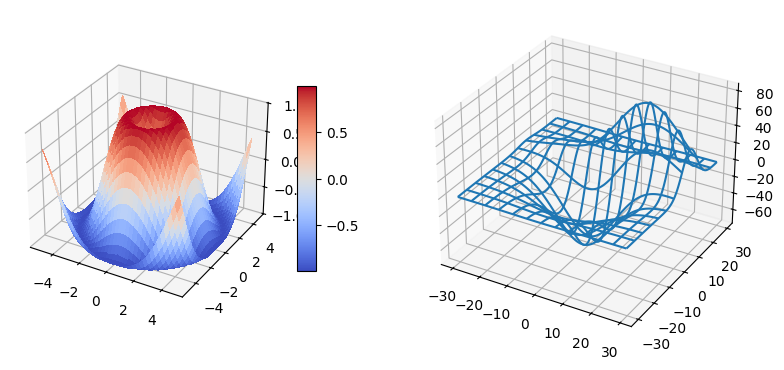

In [15]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib import cm
from mpl_toolkits.mplot3d.axes3d import get_test_data

# set up a figure twice as wide as it is tall
fig = plt.figure(figsize=plt.figaspect(0.5))

# =============
# First subplot
# =============
# set up the Axes for the first plot
ax = fig.add_subplot(1, 2, 1, projection='3d')

# plot a 3D surface like in the example mplot3d/surface3d_demo
X = np.arange(-5, 5, 0.25)
Y = np.arange(-5, 5, 0.25)
X, Y = np.meshgrid(X, Y)
R = np.sqrt(X**2 + Y**2)
Z = np.sin(R)
surf = ax.plot_surface(X, Y, Z, rstride=1, cstride=1, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)
ax.set_zlim(-1.01, 1.01)
fig.colorbar(surf, shrink=0.5, aspect=10)

# ==============
# Second subplot
# ==============
# set up the Axes for the second plot
ax = fig.add_subplot(1, 2, 2, projection='3d')

# plot a 3D wireframe like in the example mplot3d/wire3d_demo
X, Y, Z = get_test_data(0.05)
ax.plot_wireframe(X, Y, Z, rstride=10, cstride=10)

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib import cm
from mpl_toolkits.mplot3d.axes3d import get_test_data

# set up a figure twice as wide as it is tall
fig = plt.figure(figsize=plt.figaspect(0.5))

# =============
# First subplot
# =============
# set up the Axes for the first plot
ax = fig.add_subplot(1, 2, 1, projection='3d')

# plot a 3D surface like in the example mplot3d/surface3d_demo
X = np.arange(-5, 5, 0.25)
Y = np.arange(-5, 5, 0.25)
X, Y = np.meshgrid(X, Y)
R = np.sqrt(X**2 + Y**2)
Z = np.sin(R)
surf = ax.plot_surface(X, Y, Z, rstride=1, cstride=1, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)
ax.set_zlim(-1.01, 1.01)
fig.colorbar(surf, shrink=0.5, aspect=10)

# ==============
# Second subplot
# ==============
# set up the Axes for the second plot
ax = fig.add_subplot(1, 2, 2, projection='3d')

# plot a 3D wireframe like in the example mplot3d/wire3d_demo
X, Y, Z = get_test_data(0.05)
ax.plot_wireframe(X, Y, Z, rstride=10, cstride=10)

plt.show()